# Filtrado de series temporales

Este notebook prueba, sobre datos reales de Chartmetric, dos tecnicas trabajadas en la materia a partir de senales sinteticas: el filtro de media movil (`03_ Filtrado_media_movil.ipynb`) y el filtrado en el dominio de frecuencia (`Filtrado_DF.ipynb`, `04_ Filtrado_DF (1).ipynb`).

El dataset de origen es el mensual consolidado de los pilotos (`chartmetric_pilotos/600_artistas_ST_wide.csv`). La muestra sigue creciendo, asi que este notebook no fija artistas por ID: los selecciona de manera programatica en cada corrida, para poder reutilizarlo sin cambios a medida que el dataset se actualice con mas artistas.

In [1]:
# PAQUETES

library(data.table)


## 1. Configuracion y carga de datos

In [ ]:
# ============================================================
# CONFIGURACION
# ============================================================


MONTHLY_WIDE_FILE <- "850_artistas_ST_wide.csv"

FIGURES_DIR <- "figuras"

dir.create(
  FIGURES_DIR,
  showWarnings = FALSE,
  recursive = TRUE
)

# Semilla para la seleccion de artistas ilustrativos (bloque 2).
# Se sugiere repetir la seleccion con otras semillas para chequear
# que los patrones observados no dependan del artista puntual sorteado.
SEMILLA_SELECCION_ARTISTAS <- 2026

cat(
  "Dataset mensual:",
  MONTHLY_WIDE_FILE,
  "\n"
)

cat(
  "Directorio de figuras:",
  FIGURES_DIR,
  "\n"
)


Dataset mensual: 740_artistas_ST_wide.csv 
Directorio de figuras: figuras 


In [5]:
# ============================================================
# CARGA DEL DATASET MENSUAL (FORMATO ANCHO)
# ============================================================

pilotos_wide <- fread(
  MONTHLY_WIDE_FILE
)

pilotos_wide[
  ,
  month := as.Date(month)
]

setorder(
  pilotos_wide,
  artist_id,
  month
)

dim(pilotos_wide)


[1] 45676    28

In [6]:
# ------------------------------------------------------------
# CONTROL: dimensiones, periodo y cobertura general por variable
# ------------------------------------------------------------

cat(
  "Artistas:",
  uniqueN(pilotos_wide$artist_id),
  "\n"
)

cat(
  "Meses:",
  uniqueN(pilotos_wide$month),
  "\n"
)

cat(
  "Periodo:",
  format(min(pilotos_wide$month)),
  "a",
  format(max(pilotos_wide$month)),
  "\n\n"
)

variables_fan_stats <- grep(
  "^fan_stats__",
  names(pilotos_wide),
  value = TRUE
)

na_por_variable <- pilotos_wide[
  ,
  lapply(
    .SD,
    function(x) round(100 * mean(is.na(x)), 1)
  ),
  .SDcols = variables_fan_stats
]

melt(
  na_por_variable,
  measure.vars = variables_fan_stats,
  variable.name = "variable",
  value.name = "pct_na"
)[
  order(pct_na)
]


Artistas: 740 
Meses: 63 
Periodo: 2021-01-01 a 2026-03-01 



variable,pct_na
<fct>,<dbl>
fan_stats__spotify__followers,0.6
fan_stats__spotify__listeners,0.6
fan_stats__instagram__followers,15.8
fan_stats__youtube_channel__views,16.8
fan_stats__youtube_channel__subscribers,17.5
fan_stats__twitter__followers,30.6
fan_stats__youtube_artist__monthly_views,36.6
fan_stats__tiktok__followers,50.5
fan_stats__tiktok__likes,51.3


Las variables de `playlist_evolution` quedaron con 100% de nulos en este archivo (su consolidacion mensual es un pendiente aparte, ya anotado en el notebook principal). Entre las variables de Fan Stats, `fan_stats__spotify__listeners` es la de menor proporcion de nulos, asi que se usa como variable ilustrativa para probar los filtros.

## 2. Seleccion de artistas ilustrativos

Mostrar todas las trayectorias a la vez produce un grafico de espagueti dificil de leer (senalado en data-to-viz.com para graficos de lineas con demasiadas series). Para ilustrar los filtros alcanza con un puñado de artistas con cobertura completa en la variable elegida.

La seleccion replica la logica de estratificacion por rank ya usada para armar la muestra de 600 artistas (terciles en lugar de deciles, dado que aca el objetivo es solo ilustrar, no representar a toda la poblacion): se sortea un artista de cada tercil de `cm_artist_rank` entre los que tienen cobertura completa, para comparar trayectorias de artistas de alto, medio y bajo rank de popularidad.

In [7]:
# ============================================================
# SELECCION DE ARTISTAS ILUSTRATIVOS (variable con mayor cobertura)
# ============================================================

VARIABLE_ILUSTRATIVA <- "fan_stats__spotify__listeners"

total_meses_dataset <- uniqueN(pilotos_wide$month)

cobertura_por_artista <- pilotos_wide[
  ,
  .(
    n_meses = .N,
    n_na = sum(is.na(get(VARIABLE_ILUSTRATIVA)))
  ),
  by = .(
    artist_id,
    artist_name,
    cm_artist_rank
  )
]

artistas_cobertura_completa <- cobertura_por_artista[
  n_meses == total_meses_dataset &
    n_na == 0
]

cat(
  "Artistas con cobertura completa en",
  VARIABLE_ILUSTRATIVA,
  ":",
  nrow(artistas_cobertura_completa),
  "de",
  nrow(cobertura_por_artista),
  "\n"
)

# Terciles por posicion (no por valor de rank), para no depender
# de que los cortes de quantile caigan en valores repetidos.
artistas_cobertura_completa[
  ,
  tercil_rank := cut(
    frank(
      cm_artist_rank,
      ties.method = "first"
    ),
    breaks = quantile(
      frank(
        cm_artist_rank,
        ties.method = "first"
      ),
      probs = c(0, 1/3, 2/3, 1)
    ),
    include.lowest = TRUE,
    labels = c("rank_alto", "rank_medio", "rank_bajo")
  )
]

set.seed(
  SEMILLA_SELECCION_ARTISTAS
)

artistas_ilustrativos <- artistas_cobertura_completa[
  ,
  .SD[sample(.N, 1)],
  by = tercil_rank
]

artistas_ilustrativos[
  ,
  .(
    artist_id,
    artist_name,
    cm_artist_rank,
    tercil_rank
  )
]


Artistas con cobertura completa en fan_stats__spotify__listeners : 661 de 740 


artist_id,artist_name,cm_artist_rank,tercil_rank
<int>,<chr>,<int>,<fct>
4094395,Barry,2856,rank_alto
210713,Timaya,8822,rank_bajo
4333,Hayley Kiyoko,7142,rank_medio


In [8]:
# ------------------------------------------------------------
# Subconjunto de datos para los artistas ilustrativos
# ------------------------------------------------------------

ids_ilustrativos <- artistas_ilustrativos$artist_id

series_ilustrativas <- pilotos_wide[
  artist_id %in% ids_ilustrativos,
  .(
    artist_id,
    artist_name,
    month,
    valor = get(VARIABLE_ILUSTRATIVA)
  )
]

series_ilustrativas <- merge(
  series_ilustrativas,
  artistas_ilustrativos[
    ,
    .(
      artist_id,
      tercil_rank
    )
  ],
  by = "artist_id"
)

setorder(
  series_ilustrativas,
  tercil_rank,
  month
)

# reordenar ids_ilustrativos siguiendo el orden de aparicion
# en series_ilustrativas, para que lineas y leyenda coincidan
ids_ilustrativos <- unique(
  series_ilustrativas$artist_id
)

nrow(series_ilustrativas)


[1] 189

agg_record_40e060b57a16 
                      2

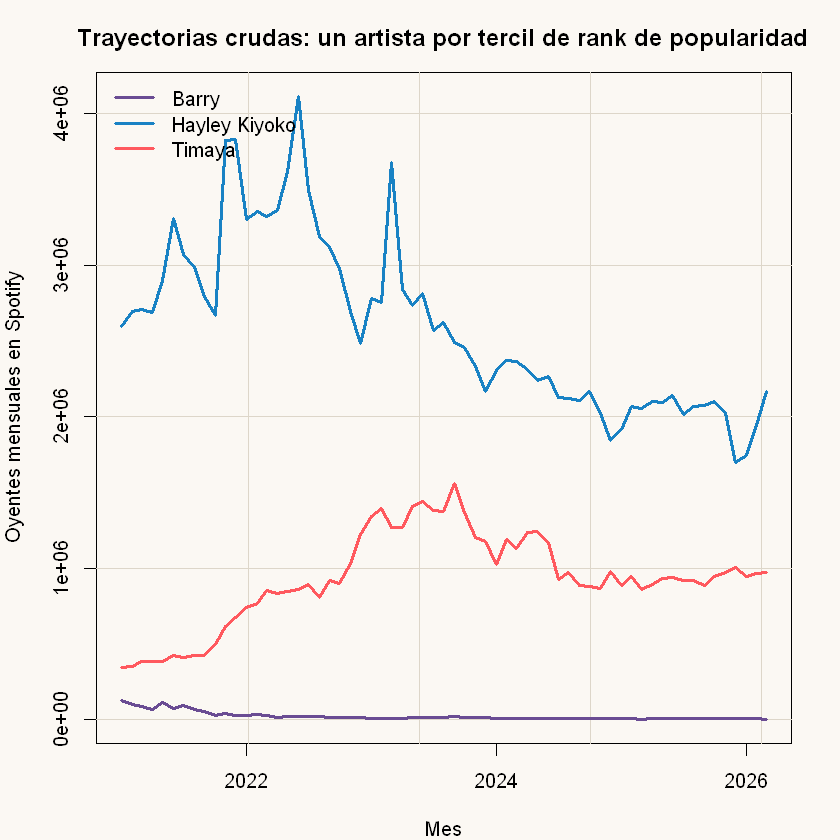

In [9]:
# ============================================================
# GRAFICO 1: trayectorias crudas de los artistas ilustrativos
# ============================================================

PALETA_ARTISTAS <- c(
  rank_alto  = "#6A4C93",
  rank_medio = "#1982C4",
  rank_bajo  = "#FF595E"
)

leyenda_artistas <- unique(
  series_ilustrativas[
    ,
    .(
      artist_id,
      artist_name,
      tercil_rank
    )
  ]
)[
  match(
    ids_ilustrativos,
    artist_id
  )
]

grafico_series_crudas <- function() {

  par(
    bg = "#FBF8F3",
    mar = c(4, 4, 3, 2)
  )

  plot(
    series_ilustrativas$month,
    series_ilustrativas$valor,
    type = "n",
    xlab = "Mes",
    ylab = "Oyentes mensuales en Spotify",
    main = "Trayectorias crudas: un artista por tercil de rank de popularidad"
  )

  grid(
    col = "#DDD6C9",
    lty = 1
  )

  for (artista_id in ids_ilustrativos) {

    serie_artista <- series_ilustrativas[
      artist_id == artista_id
    ]

    color_artista <- PALETA_ARTISTAS[
      as.character(serie_artista$tercil_rank[1])
    ]

    lines(
      serie_artista$month,
      serie_artista$valor,
      col = color_artista,
      lwd = 2.5
    )
  }

  legend(
    "topleft",
    legend = leyenda_artistas$artist_name,
    col = PALETA_ARTISTAS[
      as.character(leyenda_artistas$tercil_rank)
    ],
    lwd = 2.5,
    bty = "n"
  )
}

grafico_series_crudas()

png(
  file.path(
    FIGURES_DIR,
    "01_series_crudas_artistas_ilustrativos.png"
  ),
  width = 1400,
  height = 900,
  res = 150
)
grafico_series_crudas()
dev.off()


## 3. Filtro de media movil (ventanas mensuales)

Adaptacion de `03_ Filtrado_media_movil.ipynb`, con dos cambios frente al original:

1. Las ventanas se expresan en meses (3, 6 y 12, aproximando trimestre, semestre y anio) en lugar de dias (3, 7, 15, 25 en el notebook del profesor), porque el dataset ya esta mensualizado.
2. Se usa `frollmean` de data.table en lugar de `filter(..., circular = TRUE)`. Una trayectoria de artista no es periodica, asi que un filtro circular pegaria diciembre con enero de manera artificial; `frollmean` ademas admite `na.rm` para los meses con dato faltante, algo que las series reales de Chartmetric sí tienen.

In [10]:
# ============================================================
# MEDIAS MOVILES POR ARTISTA (ventanas de 3, 6 y 12 meses)
# ============================================================

VENTANAS_MEDIA_MOVIL <- c(3, 6, 12)

# Con ventana par, el centrado de frollmean queda levemente asimetrico
# (un mes mas hacia el pasado que hacia el futuro). Se acepta esa
# asimetria menor a cambio de ventanas con lectura directa en meses
# (trimestre, semestre, anio).

series_ilustrativas_suavizadas <- copy(
  series_ilustrativas
)

setorder(
  series_ilustrativas_suavizadas,
  artist_id,
  month
)

for (ventana in VENTANAS_MEDIA_MOVIL) {

  nombre_columna <- paste0(
    "media_movil_",
    ventana,
    "m"
  )

  series_ilustrativas_suavizadas[
    ,
    (nombre_columna) := frollmean(
      valor,
      n = ventana,
      align = "center",
      na.rm = TRUE
    ),
    by = artist_id
  ]
}


In [11]:
# ------------------------------------------------------------
# CONTROL: primeras filas de un artista, serie cruda junto a las
# tres medias moviles, para confirmar que el suavizado es razonable
# ------------------------------------------------------------

series_ilustrativas_suavizadas[
  artist_id == ids_ilustrativos[1]
][
  1:15
]


artist_id,artist_name,month,valor,tercil_rank,media_movil_3m,media_movil_6m,media_movil_12m
<int>,<chr>,<date>,<int>,<fct>,<dbl>,<dbl>,<dbl>
4094395,Barry,2021-01-01,126832,rank_alto,NA,NA,NA
4094395,Barry,2021-02-01,103070,rank_alto,105327.00,NA,NA
4094395,Barry,2021-03-01,86079,rank_alto,86647.00,95954.00,NA
4094395,Barry,2021-04-01,70792,rank_alto,89646.00,90441.67,NA
4094395,Barry,2021-05-01,112067,rank_alto,86581.00,84683.00,NA
4094395,Barry,2021-06-01,76884,rank_alto,94236.33,79201.33,74004.67
4094395,Barry,2021-07-01,93758,rank_alto,79720.00,72510.17,66001.83
4094395,Barry,2021-08-01,68518,rank_alto,71821.67,60208.67,60031.92
4094395,Barry,2021-09-01,53189,rank_alto,50784.00,52055.33,54933.17


agg_record_40e021795eb1 
                      2

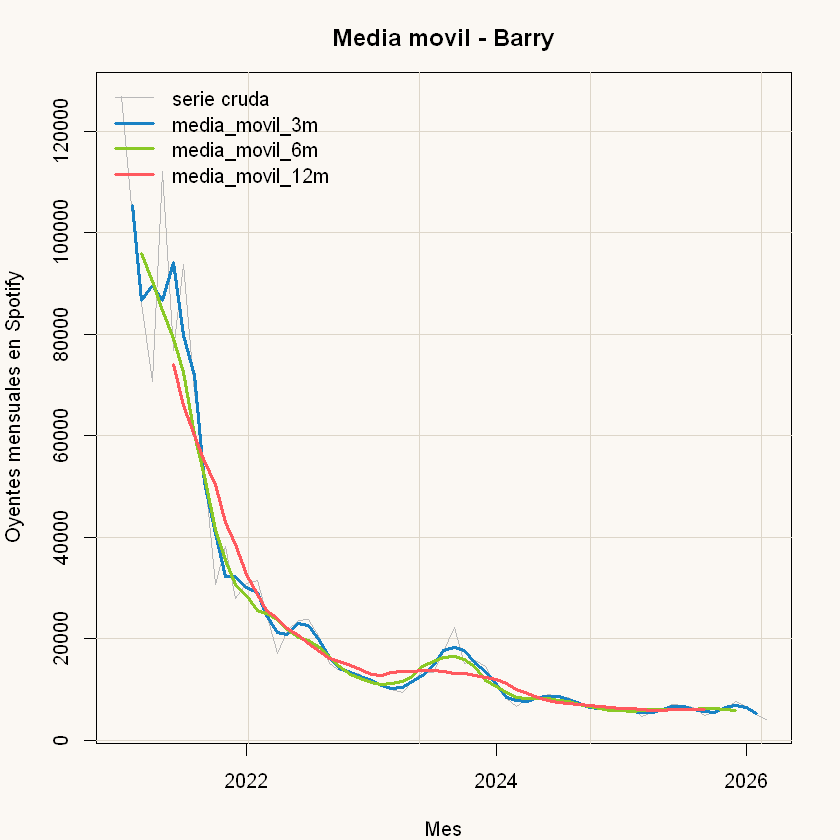

In [12]:
# ============================================================
# GRAFICO 2: medias moviles sobre un artista ilustrativo
# ============================================================

artista_foco <- ids_ilustrativos[1]

serie_foco <- series_ilustrativas_suavizadas[
  artist_id == artista_foco
]

PALETA_VENTANAS <- c(
  media_movil_3m  = "#1982C4",
  media_movil_6m  = "#8AC926",
  media_movil_12m = "#FF595E"
)

grafico_medias_moviles <- function() {

  par(
    bg = "#FBF8F3",
    mar = c(4, 4, 3, 2)
  )

  plot(
    serie_foco$month,
    serie_foco$valor,
    type = "n",
    xlab = "Mes",
    ylab = "Oyentes mensuales en Spotify",
    main = paste(
      "Media movil -",
      serie_foco$artist_name[1]
    )
  )

  grid(
    col = "#DDD6C9",
    lty = 1
  )

  lines(
    serie_foco$month,
    serie_foco$valor,
    col = "#B8B8B8",
    lwd = 1
  )

  for (columna_ventana in names(PALETA_VENTANAS)) {

    lines(
      serie_foco$month,
      serie_foco[[columna_ventana]],
      col = PALETA_VENTANAS[columna_ventana],
      lwd = 2.5
    )
  }

  legend(
    "topleft",
    legend = c("serie cruda", names(PALETA_VENTANAS)),
    col = c("#B8B8B8", unname(PALETA_VENTANAS)),
    lwd = c(1, 2.5, 2.5, 2.5),
    bty = "n"
  )
}

grafico_medias_moviles()

png(
  file.path(
    FIGURES_DIR,
    "02_media_movil_artista_foco.png"
  ),
  width = 1400,
  height = 900,
  res = 150
)
grafico_medias_moviles()
dev.off()


## 4. Filtro en el dominio de frecuencia (FFT)

Adaptacion de `Filtrado_DF.ipynb` y `04_ Filtrado_DF (1).ipynb`. La FFT necesita una serie completa y equiespaciada, sin huecos, por eso se trabaja sobre el mismo artista foco de la seccion anterior (cobertura completa garantizada por la seleccion del bloque 2). Variables con huecos frecuentes, como Twitter en el pozo de fines de 2023 detectado en el notebook principal, necesitarian primero una imputacion antes de poder aplicar este filtro.

El filtro que se construye aca es pasa-bajos: conserva las frecuencias bajas (la tendencia) y anula las altas (variacion mes a mes). Es el complemento del `filtroDF` del notebook de la materia, que anulaba las frecuencias bajas para aislar una componente de alta frecuencia escondida en una señal sintetica; aca el objetivo es el opuesto, recuperar la tendencia de una serie real.

agg_record_40e01a1e6381 
                      2

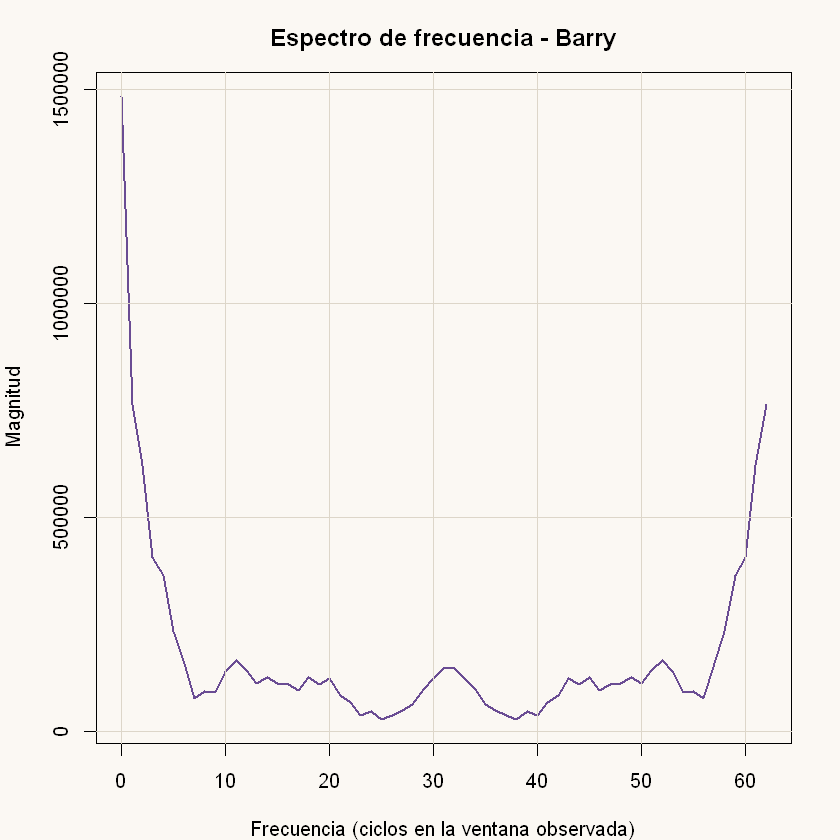

In [13]:
# ============================================================
# ESPECTRO DE FRECUENCIA DE LA SERIE FOCO
# ============================================================

n_meses_serie_foco <- nrow(serie_foco)

fft_serie_foco <- fft(
  serie_foco$valor
)

espectro_serie_foco <- Mod(
  fft_serie_foco
)

grafico_espectro <- function() {

  par(
    bg = "#FBF8F3",
    mar = c(4, 4, 3, 2)
  )

  plot(
    0:(n_meses_serie_foco - 1),
    espectro_serie_foco,
    type = "l",
    col = "#6A4C93",
    lwd = 2,
    xlab = "Frecuencia (ciclos en la ventana observada)",
    ylab = "Magnitud",
    main = paste(
      "Espectro de frecuencia -",
      serie_foco$artist_name[1]
    )
  )

  grid(
    col = "#DDD6C9",
    lty = 1
  )
}

grafico_espectro()

png(
  file.path(
    FIGURES_DIR,
    "03_espectro_frecuencia_artista_foco.png"
  ),
  width = 1400,
  height = 900,
  res = 150
)
grafico_espectro()
dev.off()


In [14]:
# ============================================================
# FILTRO PASA-BAJOS (dominio de frecuencia) SOBRE LA SERIE FOCO
# ============================================================

# Cantidad de armonicos de baja frecuencia que se conservan,
# ademas de la componente continua (frecuencia cero).
BANDA_FILTRO_PASA_BAJOS <- 6

filtro_pasa_bajos <- rep(
  0,
  n_meses_serie_foco
)

filtro_pasa_bajos[
  1:(BANDA_FILTRO_PASA_BAJOS + 1)
] <- 1

filtro_pasa_bajos[
  (n_meses_serie_foco - BANDA_FILTRO_PASA_BAJOS + 1):n_meses_serie_foco
] <- 1

fft_serie_foco_filtrada <- filtro_pasa_bajos * fft_serie_foco

serie_foco_tendencia_fft <- Re(
  fft(
    fft_serie_foco_filtrada,
    inverse = TRUE
  ) / n_meses_serie_foco
)


In [15]:
# ------------------------------------------------------------
# CONTROL: la reconstruccion conserva el largo de la serie original
# y queda en la misma escala (sin corrimientos de magnitud)
# ------------------------------------------------------------

cat(
  "Largo serie original:",
  length(serie_foco$valor),
  "\n"
)

cat(
  "Largo serie reconstruida:",
  length(serie_foco_tendencia_fft),
  "\n\n"
)

summary(
  serie_foco$valor
)

summary(
  serie_foco_tendencia_fft
)


Largo serie original: 63 
Largo serie reconstruida: 63 



   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   4120    6754   11541   23529   23677  126832 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  -1872    8237   13187   23529   26563  101166 

agg_record_40e073d53f09 
                      2

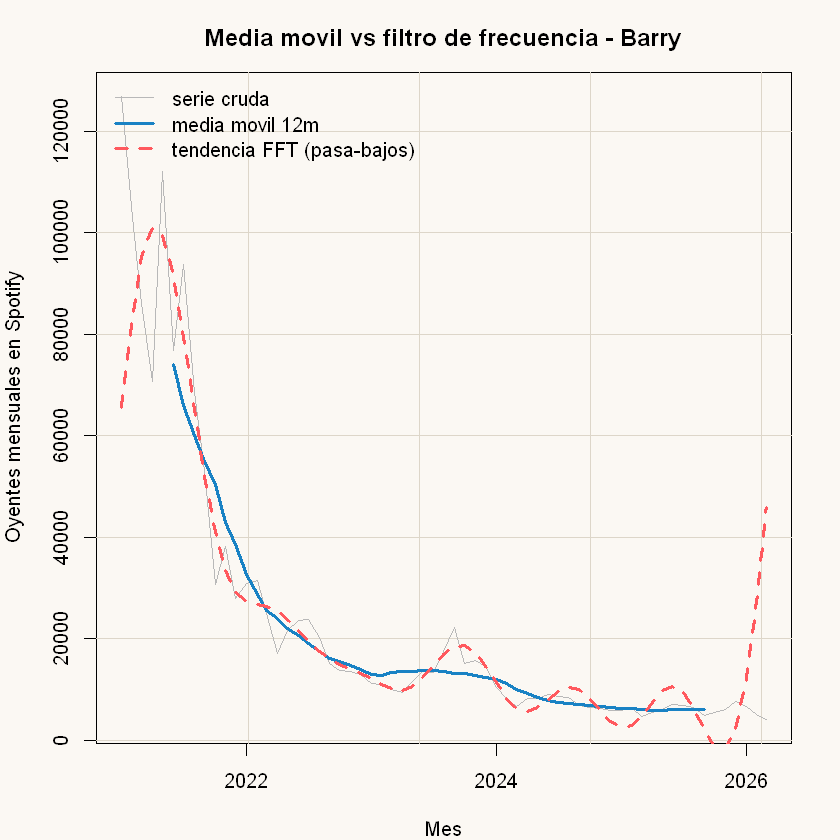

In [16]:
# ============================================================
# GRAFICO 3: media movil vs filtro de frecuencia, mismo artista
# ============================================================

grafico_comparacion_filtros <- function() {

  par(
    bg = "#FBF8F3",
    mar = c(4, 4, 3, 2)
  )

  plot(
    serie_foco$month,
    serie_foco$valor,
    type = "n",
    xlab = "Mes",
    ylab = "Oyentes mensuales en Spotify",
    main = paste(
      "Media movil vs filtro de frecuencia -",
      serie_foco$artist_name[1]
    )
  )

  grid(
    col = "#DDD6C9",
    lty = 1
  )

  lines(
    serie_foco$month,
    serie_foco$valor,
    col = "#B8B8B8",
    lwd = 1
  )

  lines(
    serie_foco$month,
    serie_foco$media_movil_12m,
    col = "#1982C4",
    lwd = 2.5
  )

  lines(
    serie_foco$month,
    serie_foco_tendencia_fft,
    col = "#FF595E",
    lwd = 2.5,
    lty = 2
  )

  legend(
    "topleft",
    legend = c(
      "serie cruda",
      "media movil 12m",
      "tendencia FFT (pasa-bajos)"
    ),
    col = c("#B8B8B8", "#1982C4", "#FF595E"),
    lwd = c(1, 2.5, 2.5),
    lty = c(1, 1, 2),
    bty = "n"
  )
}

grafico_comparacion_filtros()

png(
  file.path(
    FIGURES_DIR,
    "04_comparacion_media_movil_vs_fft.png"
  ),
  width = 1400,
  height = 900,
  res = 150
)
grafico_comparacion_filtros()
dev.off()


## 5. Que queda pendiente

1. Extender el suavizado (media movil y/o pasa-bajos) a las variables restantes y a toda la muestra, no solo a los tres artistas ilustrativos, una vez definido con que variables se arma el clustering.
2. Resolver el tratamiento de series con huecos (Twitter, TikTok) antes de poder aplicarles FFT; la media movil con `na.rm = TRUE` tolera huecos aislados pero no reemplaza una estrategia de imputacion.
3. Decidir si el insumo del clustering va a ser la serie cruda, la tendencia filtrada, el residuo (cruda menos tendencia) o alguna combinacion de las tres.
4. Repetir la seleccion de artistas ilustrativos con otras semillas (variando `SEMILLA_SELECCION_ARTISTAS`) para chequear que los patrones observados no dependan del artista puntual sorteado en cada tercil.
5. Volver a correr este notebook cuando el dataset consolidado (`600_artistas_ST_wide.csv`) se actualice con mas artistas.